## Generalized linear model - count regression

[reference](https://bambinos.github.io/bambi/notebooks/count_roaches.html)

### section I:  Bambi a high-level Bayesian model-building interface

In [1]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import nbinom

In [2]:
az.style.use("arviz-darkgrid")
SEED = 7355608

This example is based on the “Roaches” example from Regression and Other Stories by Gelman, Hill, and Vehtari. The example is a count regression model with an offset term.

The data is the number of roaches caught in 262 apartments. Some pest control treatment was applied to 158 (treatment=1) of the apartments, and 104 apartments received no treatment (treatment=0). The other columns in the data are:

- y: the number of roaches caught
- roach1 : the pre-treatment roach level
- senior : indicator for whether the appartment is for seniors
- exposure2 : the number of trap-days (number of traps x number of days).

In [ ]:
url ="https://github.com/avehtari/ROS-Examples/blob/master/Roaches/data/roaches.csv"
roaches = pd.read_csv("/mnt/e/zhaohuiwang/dev/bayesian-playground/notebooks/bambi/roaches.csv", index_col=0)
# rescale 
roaches["roach1"] = roaches["roach1"] / 100
roaches.head()

,y,roach1,treatment,senior,exposure2
1,153,3.0800,1,0,0.800000
2,127,3.3125,1,0,0.600000
3,7,0.0167,1,0,1.000000
4,7,0.0300,1,0,1.000000
5,0,0.0200,1,0,1.142857


The number of roaches caught is a Poisson random variable with a rate that is proportional to the number of trap-days (the exposure). That is: $$ y_i = Poisson(exposure2_i \times \rho_i)  \text{  where  } log(\rho_i) = \beta_0 + \beta_1treatment_i+\beta_2roach1_i + \beta_3senior_i $$
We can rewrite this as a generalized linear model: $$ y_i = Poisson(\lambda_i)  \text{  where  } log(\lambda_i) = \beta_0 + \beta_1treatment_i+\beta_2roach1_i + \beta_3senior_i + log(exposure2_i)$$ by applying the algebra (think of constant a as the exposure2) $$log(ae^x) = log(a) + log(x)$$
However, the exposure2 is just multiplier (count of traps-days) we do not need a coefficient for this term. We can simply add it as a `offset`. In bambi we do this by using the `offset` function in the formula to specify that a term should not be multiplied by a coefficient to estimate and simply added. 

In [33]:

# bambi poisson model (similar to the R format)
model_1 = bmb.Model(
    "y ~ roach1 + treatment + senior + offset(log(exposure2))",
    family = "poisson",
    data = roaches
    )

idata_1 = model_1.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, roach1, treatment, senior]


/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [34]:
az.summary(idata_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,3.089,0.021,3.049,3.129,0.000,0.0,4295.0,3540.0,1.0
roach1,0.698,0.009,0.682,0.715,0.000,0.0,3130.0,2847.0,1.0
treatment,-0.517,0.025,-0.562,-0.468,0.000,0.0,4787.0,3048.0,1.0
senior,-0.379,0.033,-0.442,-0.317,0.001,0.0,3345.0,2908.0,1.0


In [36]:
type(idata_1)
# arviz.InferenceData is a Container for inference data storage using xarray(NetCDF-like)
idata_1

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Lets see if the model predicts the distribution of roaches (y) observed. We can do this by looking at the posterior predictive distribution for the model. We plot the log of y to make the results easier to see.

In [ ]:
def plot_log_posterior_ppc(model, idata):
    """ plot posterior predictive check """
    model.predict(idata, kind='response', inplace=True)
    var_name = 'log(y+1)'
    # there is probably a better way
    idata.posterior_predictive[var_name] = np.log(idata.posterior_predictive['y'] + 1)
    idata.observed_data[var_name] = np.log(idata.observed_data['y'] + 1)
    
    return az.plot_ppc(idata, var_names=[var_name])


<Axes: xlabel='log(y+1)'>

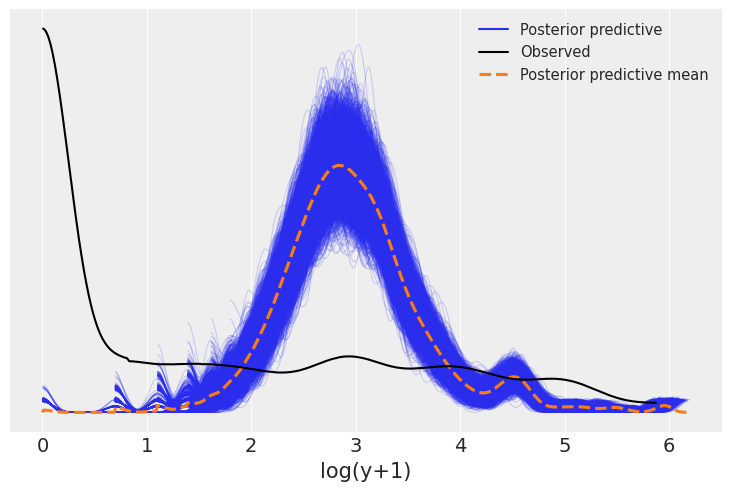

In [38]:
plot_log_posterior_ppc(model_1, idata_1)

It appears that we are drastically under predicting the number of apartments with a small number of roaches. This suggests creating a test statistic measuring the fraction of zeros, both in the observed data and in the simulated replications (posterior predictions). 

In [ ]:

idata_1
# note: posterior_predictive is added by model.predict()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [ ]:
# check number of zeros in y
def check_zeros(idata):
    # flatten over chains:
    sampled_zeros = (idata.posterior_predictive["y"]==0).mean(("__obs__")).to_numpy().flatten() # thre are 3 dimensions: ('chain', 'draw', '__obs__')
    
    print(f"Fraction of zeros in the observed data: {np.mean(roaches['y']==0)}")
    print(f"Fraction of zeros in the posterior predictive check: {np.mean(sampled_zeros)}")
    print(f" 80% CI: {np.percentile(sampled_zeros, [10, 90])}")
    
check_zeros(idata_1)

Fraction of zeros in the observed data: 0.35877862595419846
Fraction of zeros in the posterior predictive check: 0.0007223282442748091
 80% CI: [0.         0.00381679]


The Poisson model here does not succeed in reproducing the observed fraction of zeros. In the data we have about 36% zeros, while in the replications we almost always have no zeros or very few. We try an overdispersed and more flexible model like the negative binomial.

In [ ]:
# bambi Negative Binomial Fit
model_2 = bmb.Model(
    "y ~ roach1 + treatment  + senior + offset(log(exposure2))",
    family = "negativebinomial",
    data = roaches
    )

idata_2 = model_2.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, roach1, treatment, senior]


/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [54]:
az.summary(idata_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.272,0.027,0.225,0.323,0.000,0.000,6250.0,3407.0,1.0
Intercept,2.848,0.236,2.419,3.283,0.003,0.002,5553.0,3496.0,1.0
roach1,1.317,0.253,0.842,1.779,0.004,0.003,4614.0,3082.0,1.0
treatment,-0.781,0.238,-1.211,-0.327,0.003,0.002,5133.0,3174.0,1.0
senior,-0.327,0.268,-0.814,0.189,0.003,0.003,6040.0,3330.0,1.0


<Axes: xlabel='log(y+1)'>

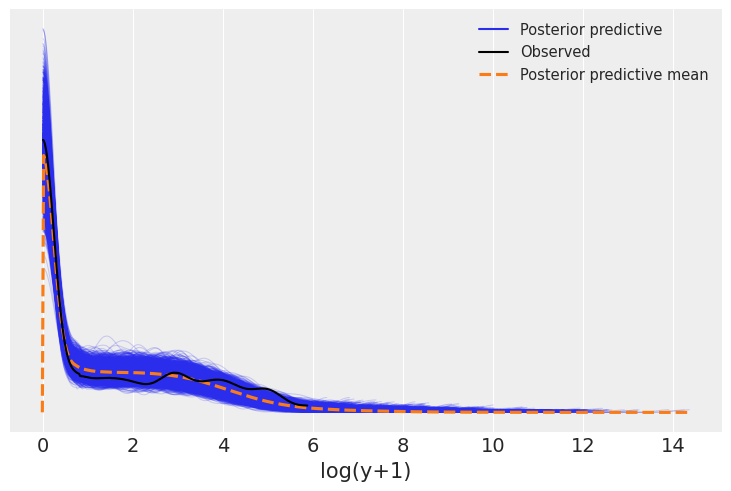

In [55]:
plot_log_posterior_ppc(model_2, idata_2)

In [56]:

check_zeros(idata_2)

Fraction of zeros in the observed data: 0.35877862595419846
Fraction of zeros in the posterior predictive check: 0.3377853053435115
 80% CI: [0.28625954 0.38931298]


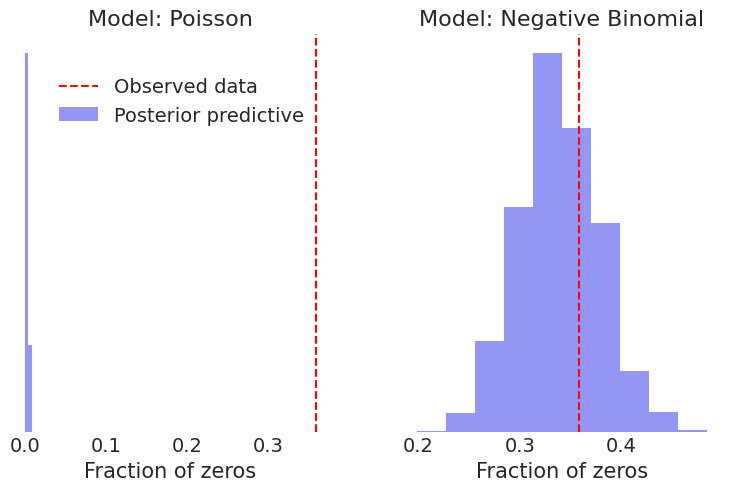

In [57]:
def plot_zeros(ax, idata, model_label, **kwargs):
    data_zeros = np.mean(roaches['y']==0)
    # flatten over chains:
    sampled_zeros = (idata.posterior_predictive["y"]==0).mean(("__obs__")).values.flatten()
    ax.hist(sampled_zeros, alpha=0.5, **kwargs)
    ax.axvline(data_zeros, color='red', linestyle='--')
    ax.set_xlabel("Fraction of zeros")
    ax.set_title(f"Model: {model_label}")
    ax.yaxis.set_visible(False)
    ax.set_facecolor('white')
    return ax

fig, ax = plt.subplots(1,2, gridspec_kw={'wspace': 0.2})
plot_zeros(ax[0],idata_1, "Poisson", bins= 2) # use 2 bins to make it more clear. Almost no zeros.
plot_zeros(ax[1],idata_2, "Negative Binomial")

fig.legend(["Observed data", "Posterior predictive"], loc='center left', bbox_to_anchor=(0.05, 0.8)) 

### section II:  PYMC equivalent model


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_roach1, beta_treatment, beta_senior, alpha]


/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


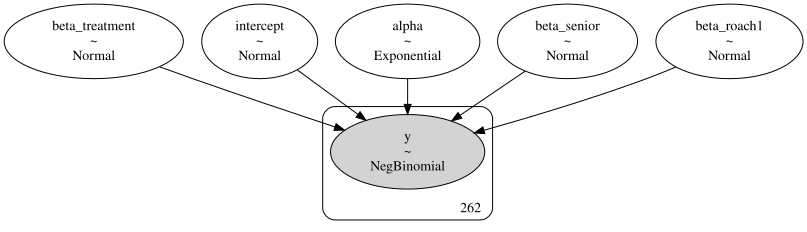

In [129]:
# recreate the model using pymc
import pymc as pm
with pm.Model() as model_pymc:
    # priors
    intercept = pm.Normal("intercept", mu=0, sigma=4.5)
    beta_roach1 = pm.Normal("beta_roach1", mu=0, sigma=3.3)
    beta_treatment = pm.Normal("beta_treatment", mu=0, sigma=5.11)
    beta_senior = pm.Normal("beta_senior", mu=0, sigma=5.43)

    alpha = pm.Exponential("alpha", 0.5)

    # linear model
    rate = (intercept + 
            beta_roach1 * roaches["roach1"] +
            beta_treatment * roaches["treatment"] +
            beta_senior * roaches["senior"] +
            pm.math.log(roaches["exposure2"]))# no beta for exposure2 
    
    # link function
    mu = pm.math.exp(rate)
    # mu = pm.Deterministic("p", pm.math.exp(rate))

    # likelihood
    #y = pm.Poisson("y", mu=mu, observed=roaches["y"])

    y = pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=roaches["y"])

    idata_pymc = pm.sample(1000)  

pm.model_to_graphviz(model_pymc)

In [130]:
# Create a data frame with summary statistics.
az.summary(idata_pymc, var_names=['intercept', 'beta_roach1','beta_treatment', 'beta_senior'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,2.845,0.228,2.411,3.273,0.005,0.003,2534.0,2302.0,1.0
beta_roach1,1.320,0.252,0.874,1.816,0.004,0.003,3455.0,2284.0,1.0
beta_treatment,-0.774,0.242,-1.213,-0.309,0.004,0.003,3202.0,2699.0,1.0
beta_senior,-0.327,0.267,-0.795,0.202,0.004,0.004,3845.0,2682.0,1.0


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'beta_roach1'}>,
        <Axes: title={'center': 'beta_treatment'}>],
       [<Axes: title={'center': 'beta_senior'}>,
        <Axes: title={'center': 'alpha'}>, <Axes: >]], dtype=object)

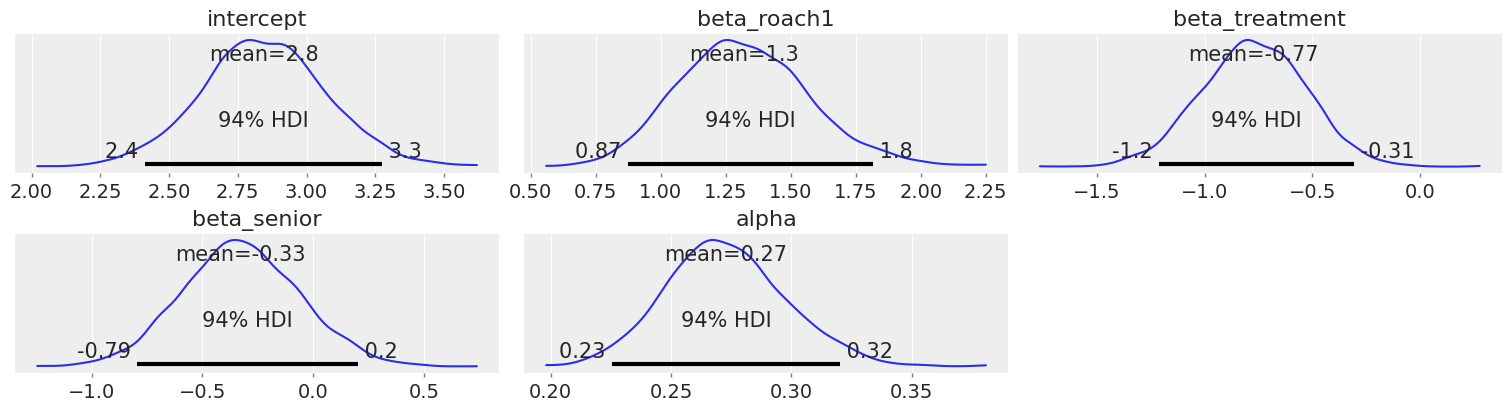

In [131]:
# Plot Posterior densities in the style of John K. Kruschke’s book.
az.plot_posterior(
    idata_pymc, 
    figsize=(15, 4)
)

In [132]:
with model_pymc:
    idata = pm.sample()
    # in-sample predictions
    posterior_predictive = pm.sample_posterior_predictive(idata).posterior_predictive

idata['posterior_predictive'] = posterior_predictive
idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_roach1, beta_treatment, beta_senior, alpha]


/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [y]


/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> posterior_predictive

<Axes: xlabel='log(y+1)'>

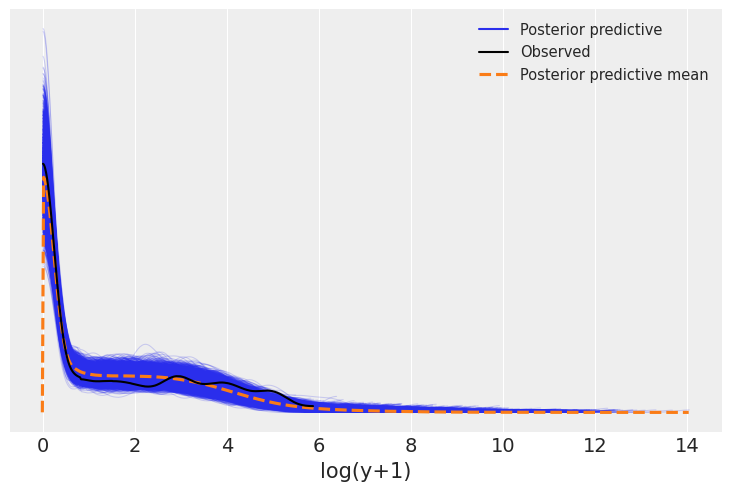

In [133]:
def plot_log_posterior_ppc2(idata):
    """ plot posterior predictive check """
    var_name = 'log(y+1)'
    # there is probably a better way
    idata.posterior_predictive[var_name] = np.log(idata.posterior_predictive['y'] + 1)
    idata.observed_data[var_name] = np.log(idata.observed_data['y'] + 1)
    
    return az.plot_ppc(idata, var_names=[var_name])


plot_log_posterior_ppc2(idata)

### section III:  statsmodels qauivalent model ????


In [ ]:
# Load modules and data
import statsmodels.api as sm

y = roaches['y']
# ?????
offset = roaches['exposure2']
# Adding a constant to the predictor variable set
X = sm.add_constant(roaches.drop('y', axis=1) )

# Instantiate a gamma family model with the default link function.
# offset ?????
gamma_model = sm.GLM(endog=y, exog=X, offset=offset, family=sm.families.NegativeBinomial())

gamma_results = gamma_model.fit()

print(gamma_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  262
Model:                            GLM   Df Residuals:                      257
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1009.7
Date:                Thu, 27 Feb 2025   Deviance:                       772.89
Time:                        19:29:52   Pearson chi2:                 1.17e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.5901
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4436      0.234     10.434      0.0

/mnt/e/zhaohuiwang/dev/bayesian-playground/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
